**Masking & Clipping:**
Reprojects all selected rasters and shapefiles to a common Swiss projected CRS (EPSG=2056). Clips and masks the Landsat time series to the Zürich West boundary and stacks all valid time steps into a single labeled xarray.Dataset. The exported .nc (NetCDF) or .zarr file is the central data object consumed by all subsequent notebooks. The output is a clean, analysis-ready data cube

In [1]:
%pip install rioxarray rasterio

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas as gpd
import xarray as xr
import rioxarray  
import matplotlib.pyplot as plt

**1.** Load the selection table and the study area boundary

In [3]:
DATA_DIR     = Path("../data/")
PROCESSED    = Path("../data/processed/")

# Load the list of usable scenes from Notebook 01
usable_df    = pd.read_csv(PROCESSED / "01_usable_scenes.csv", parse_dates=["date"])

# Load the Zürich West boundary
shapefile_path = DATA_DIR / "vector/Statistische_Quartiere.gpkg"
zurich_west_kreise  = [3, 4, 5, 9, 10]
gdf_all = gpd.read_file(
    shapefile_path, 
    layer="stzh.adm_statistische_quartiere_map")

gdf_zw         = gdf_all[gdf_all["knr"].isin(zurich_west_kreise)].copy()

print(f"Processing {len(usable_df)} scenes.")
print(f"Shapefile CRS: {gdf_zw.crs}")

Processing 14 scenes.
Shapefile CRS: EPSG:2056


**2.** Define target CRS and reproject the shapefile

In [4]:
TARGET_CRS = "EPSG:2056"

gdf_zw_proj = gdf_zw.to_crs(TARGET_CRS)

print(f"Reprojected boundary CRS: {gdf_zw_proj.crs}")

Reprojected boundary CRS: EPSG:2056


**3.** Build the xarray data cube by processing each scene

In [ ]:

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pyproj")

# Referenzgitter anhand der ersten Szene erstellen
ref_row = usable_df.iloc[0]
ref_filepath = Path("../data/raw/") / ref_row["filename"]
ref_ds = xr.open_dataset(ref_filepath, engine="rasterio")

ref_lst = ref_ds["band_data"].sel(band=7).astype('float32')
ref_lst = ref_lst.rio.write_crs(ref_row["crs"])
ref_proj = ref_lst.rio.reproject(TARGET_CRS)

# Das Referenzraster zuschneiden (hier mit drop=True, um die Ausdehnung einmalig festzulegen)
ref_clipped = ref_proj.rio.clip(gdf_zw_proj.geometry, gdf_zw_proj.crs, drop=True)

lst_slices  = []
ndvi_slices = []
timestamps  = []

for _, row in usable_df.iterrows():
    filepath = Path("../data/raw/") / row["filename"]
    date_val = row["date"]

    ds_scene = xr.open_dataset(filepath, engine="rasterio")

    red_band = ds_scene["band_data"].sel(band=3).astype('float32')
    nir_band = ds_scene["band_data"].sel(band=4).astype('float32')

    lst  = ds_scene["band_data"].sel(band=7).astype('float32')
    
    ndvi = (nir_band - red_band) / (nir_band + red_band)

    lst  = lst.rio.write_crs(row["crs"])
    ndvi = ndvi.rio.write_crs(row["crs"])
    
    # reproject_match zwingt alle Bilder auf das exakte Gitter der Referenz
    lst_proj  = lst.rio.reproject_match(ref_clipped)
    ndvi_proj = ndvi.rio.reproject_match(ref_clipped)
    
    # Clip mit drop=False haelt die Bounding Box bei allen Zeitscheiben konstant
    lst_clipped  = lst_proj.rio.clip(gdf_zw_proj.geometry, gdf_zw_proj.crs, drop=False)
    ndvi_clipped = ndvi_proj.rio.clip(gdf_zw_proj.geometry, gdf_zw_proj.crs, drop=False)
    
    lst_clipped  = lst_clipped.expand_dims(time=[date_val])
    ndvi_clipped = ndvi_clipped.expand_dims(time=[date_val])
    
    lst_slices.append(lst_clipped)
    ndvi_slices.append(ndvi_clipped)
    timestamps.append(date_val)

print(f"Processed {len(lst_slices)} scenes successfully.")

Processed 14 scenes successfully.


**4.** Combine all slices into a single xarray Dataset

In [14]:
da_lst  = xr.concat(lst_slices,  dim="time")
da_ndvi = xr.concat(ndvi_slices, dim="time")

da_lst_celsius = da_lst - 273.15

da_lst.name  = "LST"
da_lst_celsius.name = "LST_Celsius"
da_ndvi.name = "NDVI"

da_lst.attrs["units"]       = "Kelvin"
da_lst.attrs["description"] = "Land Surface Temperature from Landsat (Kelvin)"

da_lst_celsius.attrs["units"]       = "Celsius"
da_lst_celsius.attrs["description"] = "Land Surface Temperature from Landsat (Celsius)"

da_ndvi.attrs["units"]      = "dimensionless"
da_ndvi.attrs["description"] = "Normalized Difference Vegetation Index from Landsat"

ds_cube = xr.Dataset({
    "LST": da_lst, 
    "LST_Celsius": da_lst_celsius, 
    "NDVI": da_ndvi
})

print(ds_cube)
print(f"\nDimensions: {dict(ds_cube.dims)}")
print(f"Time steps: {len(ds_cube.time)}")

<xarray.Dataset> Size: 7MB
Dimensions:      (time: 14, x: 178, y: 240)
Coordinates:
  * time         (time) datetime64[us] 112B 1985-07-01 1988-07-01 ... 2024-07-01
  * x            (x) float64 1kB 2.678e+06 2.678e+06 ... 2.683e+06 2.683e+06
  * y            (y) float64 2kB 1.253e+06 1.253e+06 ... 1.246e+06 1.246e+06
    band         int64 8B 7
    spatial_ref  int64 8B 0
Data variables:
    LST          (time, y, x) float32 2MB nan nan nan nan ... nan nan nan nan
    LST_Celsius  (time, y, x) float32 2MB nan nan nan nan ... nan nan nan nan
    NDVI         (time, y, x) float32 2MB nan nan nan nan ... nan nan nan nan

Dimensions: {'time': 14, 'x': 178, 'y': 240}
Time steps: 14


/var/folders/6l/mzn01pb91mx5j6fzmnv75pgm0000gn/T/ipykernel_16492/2090170506.py:26: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"\nDimensions: {dict(ds_cube.dims)}")


**5.** NoData masking not necaserry 

**->** Quck plot of mean Land Surface Temperature across all time stamps

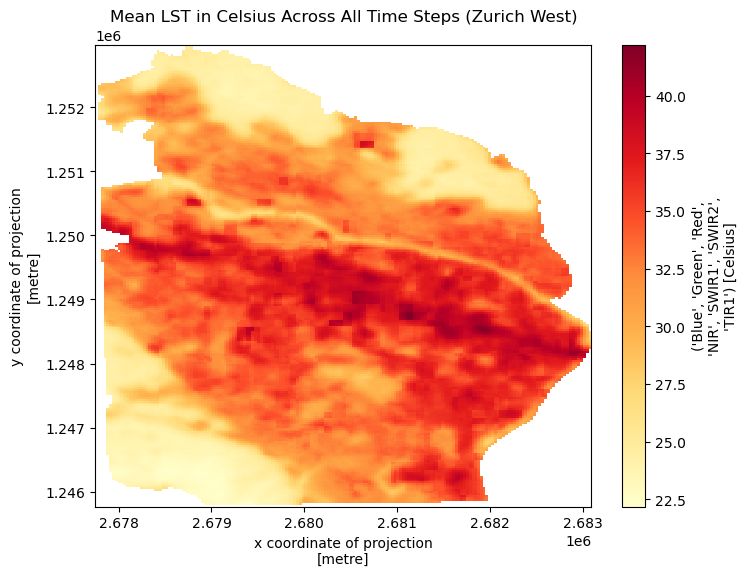

In [15]:
mean_lst_celsius = ds_cube["LST_Celsius"].mean(dim="time")

mean_lst_celsius.plot(cmap="YlOrRd", figsize=(8, 6))
plt.title("Mean LST in Celsius Across All Time Steps (Zurich West)")

plt.savefig("../figures/02_mean_lst_overview.png", dpi=300)
plt.show()

**6.** Export the processed data cube

In [ ]:
output_nc = PROCESSED / "02_zurich_west_cube.nc"
ds_cube.to_netcdf(output_nc)
print(f"Cube saved to: {output_nc}")
print(f"File size: {output_nc.stat().st_size / 1e6:.1f} MB")

Cube saved to: ../data/processed/02_zurich_west_cube.nc
File size: 7.2 MB
